
# Swiggy Business Intelligence + Machine Learning Project (Student Scaffold)

## Project Goal
You are working as a **Data Analyst at a food delivery company like Swiggy**.

Your job is to:
1. Explore the dataset
2. Generate business insights
3. Visualize important patterns
4. Build a machine learning model to predict **Order Value**
5. Interpret results like a business analyst

Dataset: `swiggy_orders_dataset.csv`



## Business Questions to Answer

1. Which city generates the highest revenue?
2. Which cuisine is the most popular?
3. Which restaurants generate the highest revenue?
4. Which city has the highest delivery time?
5. Do discounts increase order value?
6. Do highly rated orders have higher value?
7. Which cuisine has the highest average order value?
8. Does delivery time affect customer ratings?
9. Can we predict order value using machine learning?
10. What recommendations can we give to Swiggy?


## Step 1 — Import Required Libraries

   x   y
0  1  15
1  2  68
2  3  50
3  4  47
4  5  29


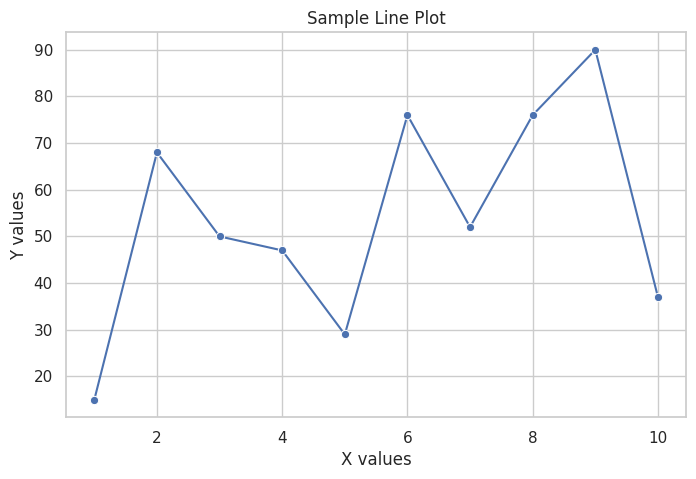

In [ ]:

# TODO:
# Import the following libraries:
# pandas
# numpy
# matplotlib.pyplot
# seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "x": np.arange(1, 11),
    "y": np.random.randint(10, 100, 10)}

df = pd.DataFrame(data)
print(df.head())

sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="x", y="y", marker="o")

plt.title("Sample Line Plot")
plt.xlabel("X values")
plt.ylabel("Y values")

plt.show()



## Step 2 — Load the Dataset

In [ ]:

# TODO:
# Load the dataset using pandas
# File name: swiggy_orders_dataset.csv

# Store it in a variable called 'data'

# Display first 5 rows

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("swiggy_orders_dataset_final.csv")
print(data.head())



   Order_ID       City      Restaurant    Cuisine  Delivery_Time  \
0      1001    Chennai   Spice Kitchen    Italian             48   
1      1002     Mumbai  Biryani Palace     Indian             25   
2      1003  Hyderabad     Street Eats    Chinese             55   
3      1004     Mumbai     Dosa Corner  Fast Food             17   
4      1005     Mumbai  Taste of India    Italian             42   

   Customer_Rating  Discount  Order_Value  
0             4.10        10          654  
1             4.97         0          471  
2             4.73        15          621  
3             4.28         0          395  
4             3.68        15          534  


## Step 3 — Understand the Dataset

In [ ]:

# TODO:
# Display dataset information
# Hint: use .info()
data.info()

# Display first 5 rows
print(data.head())

# Generate statistical summary
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         600 non-null    int64  
 1   City             600 non-null    object 
 2   Restaurant       600 non-null    object 
 3   Cuisine          600 non-null    object 
 4   Delivery_Time    600 non-null    int64  
 5   Customer_Rating  600 non-null    float64
 6   Discount         600 non-null    int64  
 7   Order_Value      600 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 37.6+ KB
   Order_ID       City      Restaurant    Cuisine  Delivery_Time  \
0      1001    Chennai   Spice Kitchen    Italian             48   
1      1002     Mumbai  Biryani Palace     Indian             25   
2      1003  Hyderabad     Street Eats    Chinese             55   
3      1004     Mumbai     Dosa Corner  Fast Food             17   
4      1005     Mumbai  Taste of 

In [ ]:

# TODO:
# Generate statistical summary of the dataset
# Hint: use .describe()
data.describe()



,Order_ID,Delivery_Time,Customer_Rating,Discount,Order_Value
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,1300.500000,36.980000,4.231917,10.175000,542.988333
std,173.349358,12.853467,0.427847,7.101297,133.792684
min,1001.000000,15.000000,3.500000,0.000000,234.000000
25%,1150.750000,26.000000,3.850000,5.000000,437.000000
50%,1300.500000,37.000000,4.230000,10.000000,539.000000
75%,1450.250000,48.000000,4.610000,15.000000,656.000000
max,1600.000000,59.000000,5.000000,20.000000,866.000000


## Step 4 — Revenue Analysis by City

In [ ]:

# TODO:
# Calculate total revenue by city
# Hint:
# groupby()
# sum()
revenue_by_city = data.groupby('City')['Order_Value'].sum().sort_values(ascending=False)

# Display the result
print(revenue_by_city)


City
Chennai      62994
Bangalore    57188
Hyderabad    51781
Mysore       51715
Pune         51593
Mumbai       50522
Name: Order_Value, dtype: int64


### Visualization: Revenue by City

In [ ]:

# TODO:
# Create a bar chart showing revenue by city

plt.figure(figsize=(10, 6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

## Step 5 — Most Popular Cuisine

In [ ]:

# TODO:
# Find how many orders exist for each cuisine
# Hint: value_counts()
cuisine_popularity = data['Cuisine'].value_counts()

# Display the result
print(cuisine_popularity)

plt.figure(figsize=(10, 6))



Cuisine
Indian          108
Italian         105
South Indian    105
Chinese         100
Desserts        100
Fast Food        82
Name: count, dtype: int64


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

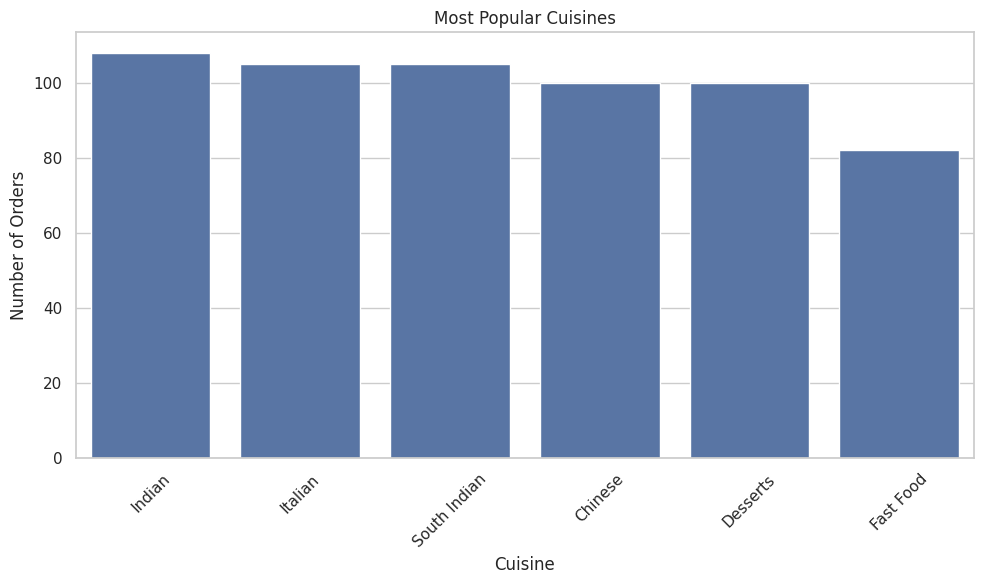

In [ ]:

# TODO:
# Create a countplot showing cuisine popularity
plt.figure(figsize=(10, 6))
sns.barplot(x=cuisine_popularity.index, y=cuisine_popularity.values)
plt.title('Most Popular Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 6 — Top Restaurants by Revenue

In [ ]:

# TODO:
# Find the top 10 restaurants based on total order value
top_10_restaurants = data.groupby('Restaurant')['Order_Value'].sum().nlargest(10)

# Display the result
print(top_10_restaurants)

plt.figure(figsize=(10, 6))


Restaurant
Cafe Delight       28488
Tandoori Treats    26551
Urban Tadka        25475
Royal Bites        24679
Spice Kitchen      23116
Street Eats        23107
Burger Point       21268
Taste of India     20341
Pizza Hub          19788
Dosa Corner        19715
Name: Order_Value, dtype: int64


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

## Step 7 — Delivery Time Analysis

In [55]:

# TODO:
# Find average delivery time for each cit
a=data.head()
print(a)





   Order_ID       City      Restaurant    Cuisine  Delivery_Time  \
0      1001    Chennai   Spice Kitchen    Italian             48   
1      1002     Mumbai  Biryani Palace     Indian             25   
2      1003  Hyderabad     Street Eats    Chinese             55   
3      1004     Mumbai     Dosa Corner  Fast Food             17   
4      1005     Mumbai  Taste of India    Italian             42   

   Customer_Rating  Discount  Order_Value  
0             4.10        10          654  
1             4.97         0          471  
2             4.73        15          621  
3             4.28         0          395  
4             3.68        15          534  


## Step 8 — Discount Impact

In [ ]:

# TODO:
# Check the average order value for each discount level
print(data.describe())

# Display dataset information
print(data.info())

# Check average order value for each discount level
avg_order_value = data.groupby("Discount")["Order_Value"].mean()
print(avg_order_value)


          Order_ID  Delivery_Time  Customer_Rating    Discount  Order_Value
count   600.000000     600.000000       600.000000  600.000000   600.000000
mean   1300.500000      36.980000         4.231917   10.175000   542.988333
std     173.349358      12.853467         0.427847    7.101297   133.792684
min    1001.000000      15.000000         3.500000    0.000000   234.000000
25%    1150.750000      26.000000         3.850000    5.000000   437.000000
50%    1300.500000      37.000000         4.230000   10.000000   539.000000
75%    1450.250000      48.000000         4.610000   15.000000   656.000000
max    1600.000000      59.000000         5.000000   20.000000   866.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         600 non-null    int64  
 1   City             600 non-null    object 
 2   Restaurant       600 no

## Step 9 — Delivery Time vs Customer Rating

In [ ]:

# TODO:
# Create a scatter plot to see relationship between delivery time and rating



## Step 10 — Prepare Data for Machine Learning

Goal: Predict **Order_Value**

Features to use:
- Delivery_Time
- Customer_Rating
- Discount


In [ ]:

# TODO:
# Define X (features) and y (target)
X = data[['Delivery_Time', 'Customer_Rating', 'Discount']]
y = data['Order_Value']

# Display first 5 rows of X and y
print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())


Features (X) head:
   Delivery_Time  Customer_Rating  Discount
0             48             4.10        10
1             25             4.97         0
2             55             4.73        15
3             17             4.28         0
4             42             3.68        15

Target (y) head:
0    654
1    471
2    621
3    395
4    534
Name: Order_Value, dtype: int64


## Step 11 — Train Test Split

In [ ]:

# TODO:
# Split the dataset into training and testing sets
# Hint: train_test_split()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the split datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (480, 3)
X_test shape: (120, 3)
y_train shape: (480,)
y_test shape: (120,)


## Step 12 — Train Machine Learning Model

In [ ]:

# TODO:
# Import LinearRegression
# Train the model using training data
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


## Step 13 — Make Predictions

In [ ]:

# TODO:
# Predict order values using the test dataset
y_pred = model.predict(X_test)


## Step 14 — Evaluate Model Performance

In [ ]:

# TODO:
# Calculate Mean Absolute Error
# Calculate R2 Score
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.2f}")


Mean Absolute Error: 111.00
R2 Score: 0.09



## Step 15 — Predict New Order Value

Example:
Delivery Time = 25 minutes  
Customer Rating = 4.6  
Discount = 10%


In [ ]:

# TODO:
# Use the trained model to predict order value for a new example

# Example values:
new_delivery_time = 25
new_customer_rating = 4.6
new_discount = 10

# Create a DataFrame for the new example, matching the features X
new_order_data = pd.DataFrame([[new_delivery_time, new_customer_rating, new_discount]],
                            columns=['Delivery_Time', 'Customer_Rating', 'Discount'])

# Predict the order value for the new example
predicted_order_value = model.predict(new_order_data)

print(f"Predicted Order Value for the new example: {predicted_order_value[0]:.2f}")


Predicted Order Value for the new example: 564.33



## Final Task — Business Recommendations

Write 3 recommendations for Swiggy based on your analysis.

Examples:
- Improve delivery time in certain cities
- Promote popular cuisines
- Offer targeted discounts


In [ ]:
a=data.head()
print(a)

   Order_ID       City      Restaurant    Cuisine  Delivery_Time  \
0      1001    Chennai   Spice Kitchen    Italian             48   
1      1002     Mumbai  Biryani Palace     Indian             25   
2      1003  Hyderabad     Street Eats    Chinese             55   
3      1004     Mumbai     Dosa Corner  Fast Food             17   
4      1005     Mumbai  Taste of India    Italian             42   

   Customer_Rating  Discount  Order_Value  
0             4.10        10          654  
1             4.97         0          471  
2             4.73        15          621  
3             4.28         0          395  
4             3.68        15          534  
